# 02 – Exploration der TESS-Lichtkurven

## Ziel

In diesem Notebook werden die tatsächlichen TESS-Lichtkurven
für ausgewählte TOIs geladen und untersucht.

Im Folgenden wird behandelt:

- supervised TOI-Kandidaten laden
- Beispielobjekte auswählen
- verfügbare TESS-Lichtkurven suchen
- Lichtkurve herunterladen
- Flux und Quality Flags untersuchen
- Lichtkurve bereinigen
- normalisieren
- Phase Folding durchführen
- Global View und Local View erzeugen

#### Bibliotheken

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from tqdm.auto import tqdm

#### Projektpfade

In [2]:
cwd = Path.cwd()

if cwd.name.lower() == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
LIGHTCURVE_DIR = PROJECT_ROOT / "data" / "raw" / "lightcurves"

LIGHTCURVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Lightcurve directory:", LIGHTCURVE_DIR)

Project root: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets
Lightcurve directory: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\raw\lightcurves


#### Gelabelte TOI-Daten aus Notebook 1 laden

In [3]:
snapshot_date = "2026-08-16"

supervised_file = (
    INTERIM_DIR
    / f"toi_supervised_candidates_{snapshot_date}.csv"
)

supervised = pd.read_csv(supervised_file)

print("TOIs:", len(supervised))

supervised.head()

TOIs: 2663


,toi,tid,tfopwg_disp,pl_orbper,pl_tranmid,pl_trandurh,pl_trandep,st_tmag,st_teff,st_rad,ra,dec,toi_created,rowupdate,label
0,1064.01,79748331,CP,6.443866,2.458657e+06,1.930945,1121.951227,10.0059,4803.0,0.737189,296.003935,-47.562030,2019-08-16 20:20:42,2024-04-25 10:08:01,1
1,1064.02,79748331,CP,12.226560,2.458664e+06,2.190438,1206.369329,10.0059,4803.0,0.737189,296.003935,-47.562030,2019-08-16 20:20:42,2024-04-25 10:08:01,1
2,1065.01,7088246,KP,2.160515,2.458654e+06,1.480696,13774.879462,13.2851,5780.0,1.200000,286.366750,-50.067350,2019-08-16 20:20:41,2026-04-15 10:08:02,1
3,1066.01,201604954,KP,4.606184,2.458658e+06,3.121643,13793.034867,11.9707,5670.0,1.070000,285.096517,-54.893341,2019-08-16 20:20:44,2021-10-29 12:59:15,1
4,1067.01,201642601,KP,3.131674,2.458657e+06,2.457920,14915.694372,13.1686,4351.0,0.767010,288.672005,-59.579350,2019-08-16 20:20:44,2024-03-14 16:54:32,1


#### Klasssenverteilung

In [4]:
supervised["label"].value_counts()

label
0    1339
1    1324
Name: count, dtype: int64

#### Transitparamter eines Planeten (Beispiel)

In [5]:
planet_example = (
    supervised[
        supervised["label"] == 1
    ]
    .iloc[0]
)

planet_example[
    [
        "toi",
        "tid",
        "tfopwg_disp",
        "pl_orbper",
        "pl_tranmid",
        "pl_trandurh"
    ]
]

toi                   1064.01
tid                  79748331
tfopwg_disp                CP
pl_orbper            6.443866
pl_tranmid     2458656.668478
pl_trandurh          1.930945
Name: 0, dtype: object

#### Lichtkurve suchen

In [7]:
tic_id = int(planet_example["tid"])

search_result = lk.search_lightcurve(
    f"TIC {tic_id}",
    mission="TESS"
)

search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 13,2019,SPOC,120,79748331,0.0
1,TESS Sector 27,2020,SPOC,20,79748331,0.0
2,TESS Sector 27,2020,SPOC,120,79748331,0.0
3,TESS Sector 67,2023,SPOC,20,79748331,0.0
4,TESS Sector 67,2023,SPOC,120,79748331,0.0
5,TESS Sector 94,2025,SPOC,20,79748331,0.0
6,TESS Sector 94,2025,SPOC,120,79748331,0.0
7,TESS Sector 104,2026,SPOC,20,79748331,0.0
8,TESS Sector 105,2026,SPOC,20,79748331,0.0


#### Auf SPOC-Lichtkurven mit einer Kadenz von 120s filtern

In [8]:
spoc_120 = lk.search_lightcurve(
    f"TIC {tic_id}",
    mission="TESS",
    author="SPOC",
    exptime=120
)

spoc_120

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 13,2019,SPOC,120,79748331,0.0
1,TESS Sector 27,2020,SPOC,120,79748331,0.0
2,TESS Sector 67,2023,SPOC,120,79748331,0.0
3,TESS Sector 94,2025,SPOC,120,79748331,0.0
4,TESS Sector 104,2026,SPOC,120,79748331,0.0
5,TESS Sector 105,2026,SPOC,120,79748331,0.0


#### Ersten SPOC-Sektor für das Beispiel laden

In [9]:
lc = spoc_120[0].download()

lc

time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1653.942120441185,———,———,4.8722392e-03,307067,1255.17855,703.99547,1.4918067e+04,3.0847569e+01,4.0735418e+04,1.7876196e+01,———,———,11000000000000,———,———,———,———,1255.17855,1.9213189e-03,703.99547,1.6595848e-03,-2.3601992e-02,-1.0062421e-01
1653.943509370926,———,———,4.8722806e-03,307068,1255.17272,703.98958,1.4921699e+04,3.0766987e+01,4.0444602e+04,1.7819813e+01,———,———,11000000000000,———,———,———,———,1255.17272,1.9162575e-03,703.98958,1.6565415e-03,-2.4348523e-02,-1.0801895e-01
1653.9448983011323,———,———,4.8723225e-03,307069,1255.17556,703.99584,1.4939488e+04,3.0605991e+01,3.9943113e+04,1.7702597e+01,———,———,11000000000000,———,———,———,———,1255.17556,1.9037328e-03,703.99584,1.6435697e-03,-2.3916455e-02,-1.0050855e-01
1653.9546208107138,———,———,4.8726141e-03,307076,1255.17502,703.98937,1.4888812e+04,3.0240530e+01,3.8811785e+04,1.7453279e+01,———,———,11000000000000,———,———,———,———,1255.17502,1.8862627e-03,703.98937,1.6311986e-03,-2.3435032e-02,-1.0786804e-01
1653.956009740454,———,———,4.8726555e-03,307077,1255.17287,703.99352,1.4922138e+04,3.0229914e+01,3.8752285e+04,1.7443905e+01,———,———,11000000000000,———,———,———,———,1255.17287,1.8816079e-03,703.99352,1.6252804e-03,-2.5040695e-02,-1.0249452e-01
1653.9573986706598,———,———,4.8726974e-03,307078,1255.17211,703.99398,1.4908927e+04,3.0213224e+01,3.8683434e+04,1.7428749e+01,———,———,11000000000000,———,———,———,———,1255.17211,1.8821078e-03,703.99398,1.6264968e-03,-2.3170620e-02,-1.0305707e-01
1653.9671211788448,———,———,4.8729875e-03,307085,1255.17374,703.99552,1.4933003e+04,2.9938826e+01,3.7824910e+04,1.7237364e+01,———,———,11000000000000,———,———,———,———,1255.17374,1.8607957e-03,703.99552,1.6082251e-03,-2.3570200e-02,-1.0255814e-01
1653.9685101085863,———,———,4.8730290e-03,307086,1255.17336,703.99820,1.4861285e+04,2.9910440e+01,3.7776254e+04,1.7221470e+01,———,———,11000000000000,———,———,———,———,1255.17336,1.8675604e-03,703.99820,1.6128734e-03,-2.4604781e-02,-9.9832095e-02


#### Lichtkurve des Sterns visuell

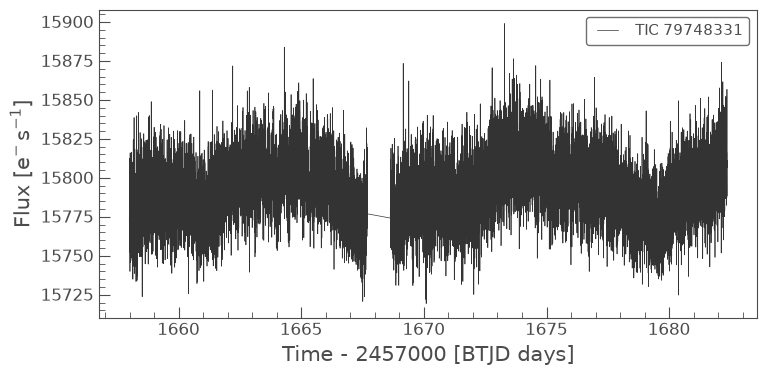

In [10]:
lc.plot()
plt.show()

#### Datenquelle dokumentieren

In [11]:
print("TIC:", lc.meta.get("TARGETID"))
print("Sector:", lc.meta.get("SECTOR"))
print("Flux-Spalte:", lc.meta.get("FLUX_ORIGIN"))
print("Anzahl Messpunkte:", len(lc))

print("Zeitformat:", lc.time.format)
print("Zeitskala:", lc.time.scale)

TIC: 79748331
Sector: 13
Flux-Spalte: pdcsap_flux
Anzahl Messpunkte: 19262
Zeitformat: btjd
Zeitskala: tdb


#### Fehlende Flux-Werte entfernen

In [12]:
lc_clean = lc.remove_nans()

print("Vorher:", len(lc))
print("Nach NaN-Entfernung:", len(lc_clean))

Vorher: 19262
Nach NaN-Entfernung: 16591


#### Normalisiereung auf Median-Flux
Relative Helligkeitsänderung:
normalize() teilt Flux und Flux-Fehler durch den Median der Lichtkurve. Danach liegt der normale Sternflux ungefähr bei 1.0

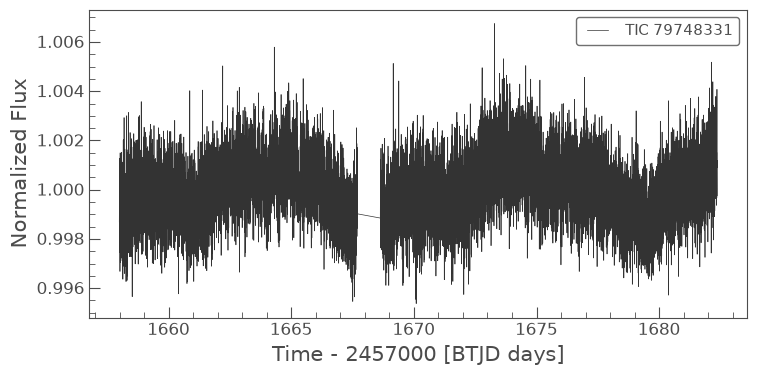

In [13]:
lc_norm = lc_clean.normalize()

lc_norm.plot()
plt.show()

In [14]:
period = float(planet_example["pl_orbper"])
transit_mid_bjd = float(planet_example["pl_tranmid"])
duration_hours = float(planet_example["pl_trandurh"])

print("Periode:", period, "Tage")
print("Transitmittelpunkt:", transit_mid_bjd, "BJD")
print("Transitdauer:", duration_hours, "Stunden")

Periode: 6.4438657 Tage
Transitmittelpunkt: 2458656.668478 BJD
Transitdauer: 1.9309449 Stunden


#### Transitzeitpunkt von BJD zu TESS-BTJD konvertieren

In [15]:
transit_mid_btjd = transit_mid_bjd - 2457000

print("Transitmittelpunkt BJD: ", transit_mid_bjd)
print("Transitmittelpunkt BTJD:", transit_mid_btjd)

Transitmittelpunkt BJD:  2458656.668478
Transitmittelpunkt BTJD: 1656.6684779999778


### Phase Folding
Alle Umläufe von 6.4438657 Tagen übereinander legen. Faltet die Lichtkurve anhand der Orbitalperiode.

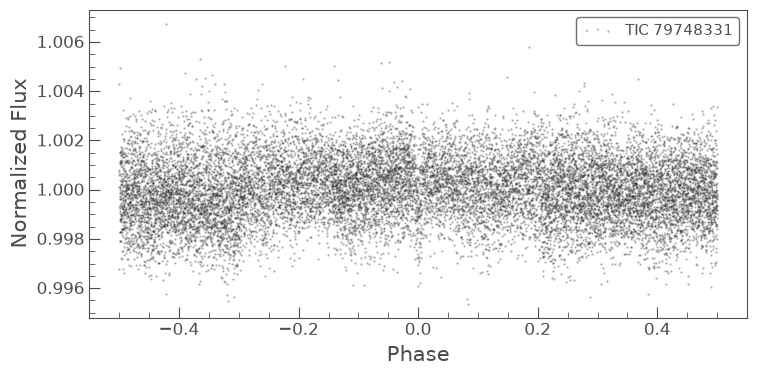

In [16]:
folded = lc_norm.fold(
    period=period,
    epoch_time=transit_mid_btjd,
    normalize_phase=True
)

folded.scatter(
    s=2,
    alpha=0.3
)

plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.show()

#### Transitdauer in Tage und Phasen konvertieren

In [17]:
duration_days = duration_hours / 24
duration_phase = duration_days / period

print("Transitdauer [Tage]:", duration_days)
print("Transitdauer [Phase]:", duration_phase)

Transitdauer [Tage]: 0.08045603750000001
Transitdauer [Phase]: 0.012485678821642731


#### Transit als Local View

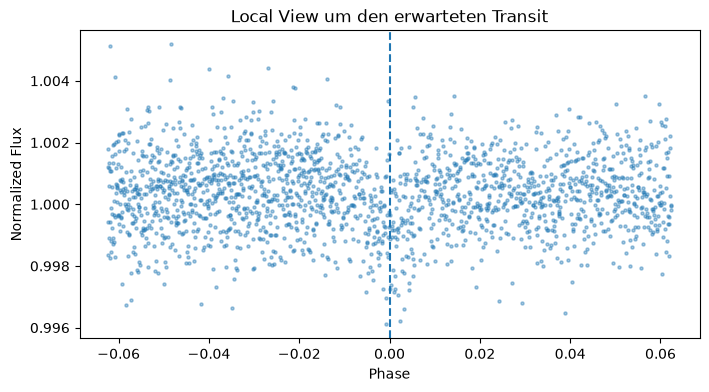

In [18]:
phase = folded.time.value
flux = folded.flux.value

window = 5 * duration_phase

mask = abs(phase) <= window

plt.figure(figsize=(8, 4))
plt.scatter(
    phase[mask],
    flux[mask],
    s=5,
    alpha=0.4
)

plt.axvline(0, linestyle="--")

plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.title("Local View um den erwarteten Transit")
plt.show()

#### Alle SPOC-120s-Sektoren aus dem Beispielstern laden

In [21]:
lightcurves = spoc_120.download_all()

print("Geladene Lichtkurven:", len(lightcurves))

for lc_sector in lightcurves:
    print(
        "Sector:",
        lc_sector.meta.get("SECTOR"),
        "| Messpunkte:",
        len(lc_sector)
    )

Geladene Lichtkurven: 6
Sector: 13 | Messpunkte: 19262
Sector: 27 | Messpunkte: 16779
Sector: 67 | Messpunkte: 16380
Sector: 94 | Messpunkte: 16837
Sector: 104 | Messpunkte: 17606
Sector: 105 | Messpunkte: 16937


#### Jeden Sektor normalisieren

In [22]:
normalized_lightcurves = []

for lc_sector in lightcurves:
    lc_sector = lc_sector.remove_nans()
    lc_sector = lc_sector.normalize()

    normalized_lightcurves.append(lc_sector)

#### Gemeinsame Lichtkurve der normalisierten Sektoren

In [23]:
lc_all = lk.LightCurveCollection(
    normalized_lightcurves
).stitch(
    corrector_func=lambda x: x
)

print("Messpunkte insgesamt:", len(lc_all))

Messpunkte insgesamt: 87292


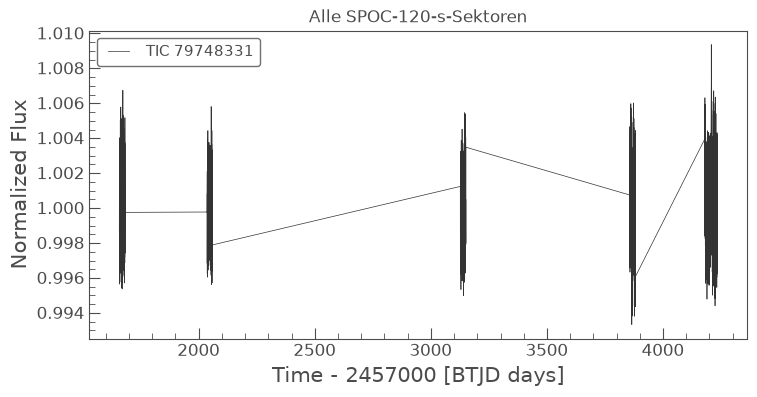

In [24]:
lc_all.plot()

plt.title("Alle SPOC-120-s-Sektoren")
plt.show()

#### Phase Folding aller Sektoren

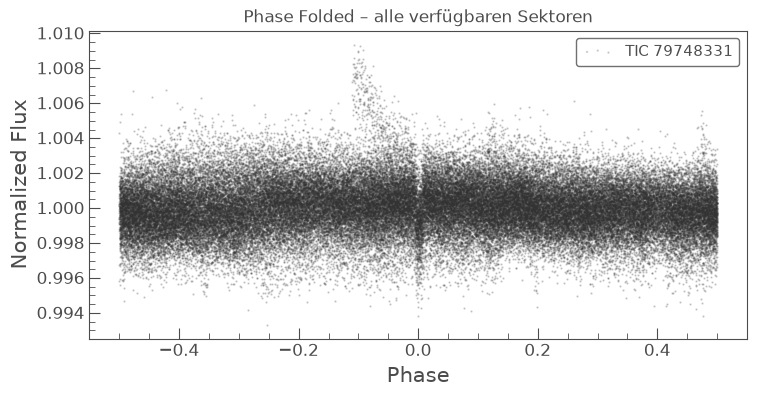

In [26]:
folded_all = lc_all.fold(
    period=period,
    epoch_time=transit_mid_btjd,
    normalize_phase=True
)

folded_all.scatter(
    s=2,
    alpha=0.2
)

plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.title("Phase Folded – alle verfügbaren Sektoren")
plt.show()

#### Local View

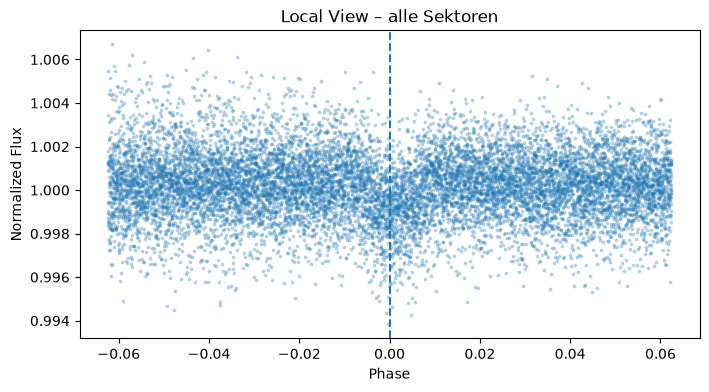

In [27]:
phase_all = folded_all.time.value
flux_all = folded_all.flux.value

window = 5 * duration_phase

mask_all = (
    np.abs(phase_all) <= window
)

plt.figure(figsize=(8, 4))

plt.scatter(
    phase_all[mask_all],
    flux_all[mask_all],
    s=3,
    alpha=0.25
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.title("Local View – alle Sektoren")

plt.show()

#### Funktion für das Binning von Phasenlichtkurven

In [28]:
def bin_phase_curve(phase, flux, phase_min, phase_max, n_bins):
    bin_edges = np.linspace(
        phase_min,
        phase_max,
        n_bins + 1
    )

    bin_centers = (
        bin_edges[:-1] + bin_edges[1:]
    ) / 2

    binned_flux = np.full(
        n_bins,
        np.nan
    )

    for i in range(n_bins):
        mask = (
            (phase >= bin_edges[i]) &
            (phase < bin_edges[i + 1])
        )

        if np.any(mask):
            binned_flux[i] = np.median(
                flux[mask]
            )

    return bin_centers, binned_flux

#### Local View mit zunächst 201 Bins aus dem Transitbereich

In [29]:
n_local_bins = 201

local_phase = phase_all[mask_all]
local_flux = flux_all[mask_all]

local_bin_centers, local_binned_flux = bin_phase_curve(
    phase=local_phase,
    flux=local_flux,
    phase_min=-window,
    phase_max=window,
    n_bins=n_local_bins
)

print("Local View Länge:", len(local_binned_flux))
print("Leere Bins:", np.isnan(local_binned_flux).sum())

Local View Länge: 201
Leere Bins: 0


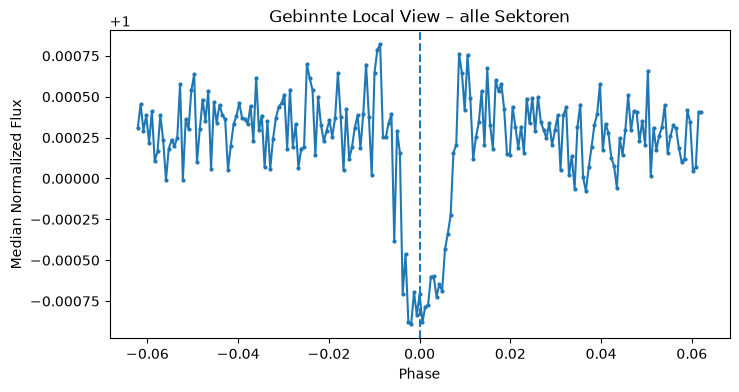

In [30]:
plt.figure(figsize=(8, 4))

plt.plot(
    local_bin_centers,
    local_binned_flux,
    marker=".",
    markersize=4
)

plt.axvline(0, linestyle="--")

plt.xlabel("Phase")
plt.ylabel("Median Normalized Flux")
plt.title("Gebinnte Local View – alle Sektoren")

plt.show()

#### Global View mit zunächst 2001 Bins aus dem vollständigen Phasenbereich

In [31]:
n_global_bins = 2001

global_bin_centers, global_binned_flux = bin_phase_curve(
    phase=phase_all,
    flux=flux_all,
    phase_min=-0.5,
    phase_max=0.5,
    n_bins=n_global_bins
)

print("Global View Länge:", len(global_binned_flux))
print("Leere Bins:", np.isnan(global_binned_flux).sum())

Global View Länge: 2001
Leere Bins: 0


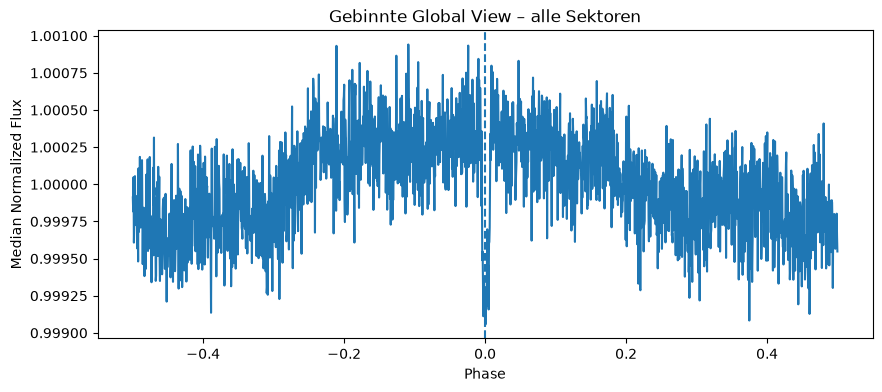

In [32]:
plt.figure(figsize=(10, 4))

plt.plot(
    global_bin_centers,
    global_binned_flux
)

plt.axvline(0, linestyle="--")

plt.xlabel("Phase")
plt.ylabel("Median Normalized Flux")
plt.title("Gebinnte Global View – alle Sektoren")

plt.show()

#### Faltung jedes einzelnen Sektor

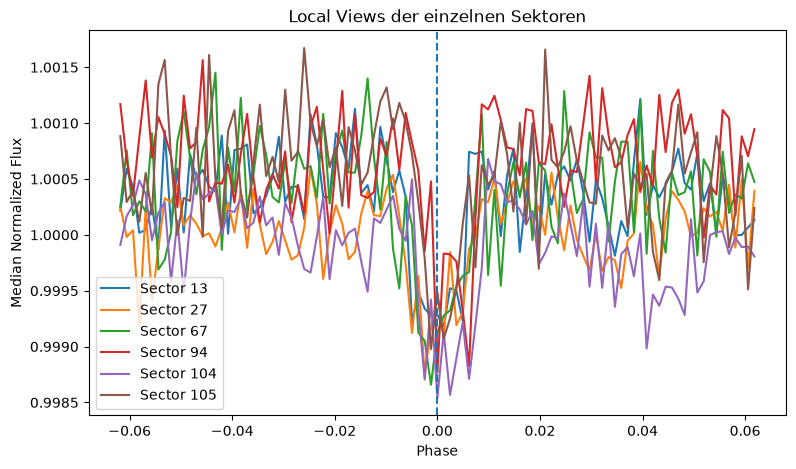

In [33]:
plt.figure(figsize=(9, 5))

for lc_sector in normalized_lightcurves:
    sector = lc_sector.meta.get("SECTOR")

    folded_sector = lc_sector.fold(
        period=period,
        epoch_time=transit_mid_btjd,
        normalize_phase=True
    )

    sector_phase = folded_sector.time.value
    sector_flux = folded_sector.flux.value

    sector_mask = (
        np.abs(sector_phase) <= window
    )

    centers, binned = bin_phase_curve(
        phase=sector_phase[sector_mask],
        flux=sector_flux[sector_mask],
        phase_min=-window,
        phase_max=window,
        n_bins=101
    )

    plt.plot(
        centers,
        binned,
        label=f"Sector {sector}"
    )

plt.axvline(0, linestyle="--")

plt.xlabel("Phase")
plt.ylabel("Median Normalized Flux")
plt.title("Local Views der einzelnen Sektoren")

plt.legend()
plt.show()

In [34]:
print(
    "Global View:",
    len(global_binned_flux),
    "Bins, davon",
    np.isnan(global_binned_flux).sum(),
    "leer"
)

print(
    "Local View:",
    len(local_binned_flux),
    "Bins, davon",
    np.isnan(local_binned_flux).sum(),
    "leer"
)

Global View: 2001 Bins, davon 0 leer
Local View: 201 Bins, davon 0 leer


In [35]:
local_baseline = np.nanmedian(local_binned_flux)

local_view = (
    local_binned_flux - local_baseline
)

In [36]:
print("Median vorher:", np.nanmedian(local_binned_flux))
print("Median nachher:", np.nanmedian(local_view))

Median vorher: 1.0002963542938232
Median nachher: 0.0


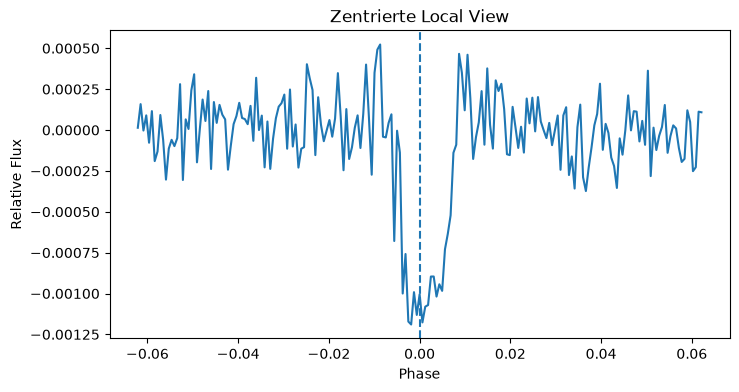

In [37]:
plt.figure(figsize=(8, 4))

plt.plot(
    local_bin_centers,
    local_view
)

plt.axvline(0, linestyle="--")

plt.xlabel("Phase")
plt.ylabel("Relative Flux")
plt.title("Zentrierte Local View")

plt.show()

In [38]:
global_baseline = np.nanmedian(global_binned_flux)

global_view = (
    global_binned_flux - global_baseline
)

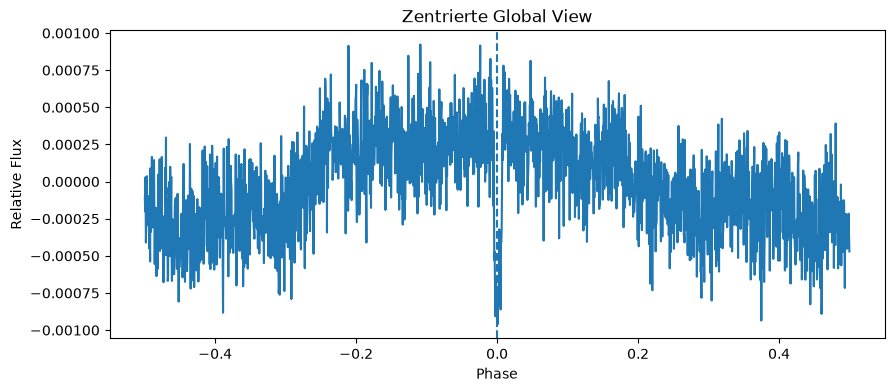

In [39]:
plt.figure(figsize=(10, 4))

plt.plot(
    global_bin_centers,
    global_view
)

plt.axvline(0, linestyle="--")

plt.xlabel("Phase")
plt.ylabel("Relative Flux")
plt.title("Zentrierte Global View")

plt.show()

Hier in der Untersuchung des Datensatzes wurde die Auflösung von 2001 Global-Bins und 201 Local-Bins verwendet. Diese Auflösung wird später in Notebook03 angepasst.

## Test für Nicht-Planet (FP/FA)

#### Beispiel eines sicher gelabelten Nicht-Planeten

In [46]:
negative_example = (
    supervised[
        supervised["label"] == 0
    ]
    .iloc[0]
)

negative_example[
    [
        "toi",
        "tid",
        "tfopwg_disp",
        "pl_orbper",
        "pl_tranmid",
        "pl_trandurh"
    ]
]

toi                   1070.01
tid                  31858844
tfopwg_disp                FP
pl_orbper            2.977615
pl_tranmid     2458655.579241
pl_trandurh           3.25697
Name: 8, dtype: object

#### 120s-Lichtkurve suchen

In [47]:
negative_tic_id = int(negative_example["tid"])

negative_search = lk.search_lightcurve(
    f"TIC {negative_tic_id}",
    mission="TESS",
    author="SPOC",
    exptime=120
)

negative_search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 13,2019,SPOC,120,31858844,0.0
1,TESS Sector 27,2020,SPOC,120,31858844,0.0


#### Alle verfügbaren Sektoren der Nicht-Plneten herunterladen

In [48]:
if len(negative_search) == 0:
    raise ValueError(
        f"Keine SPOC-120-s-Lichtkurven für TIC {negative_tic_id} gefunden."
    )

negative_lightcurves = negative_search.download_all()

print("Geladene Lichtkurven:", len(negative_lightcurves))

for lc_sector in negative_lightcurves:
    print(
        "Sector:",
        lc_sector.meta.get("SECTOR"),
        "| Messpunkte:",
        len(lc_sector)
    )

Geladene Lichtkurven: 2
Sector: 13 | Messpunkte: 18441
Sector: 27 | Messpunkte: 16780


In [49]:
negative_normalized = []

for lc_sector in negative_lightcurves:
    lc_sector = lc_sector.remove_nans()
    lc_sector = lc_sector.normalize()

    negative_normalized.append(lc_sector)

print(
    "Normalisierte Sektoren:",
    len(negative_normalized)
)

Normalisierte Sektoren: 2


#### Gemeinsame Lichtkurve aller normalisierten Sektoren

In [50]:
negative_lc_all = lk.LightCurveCollection(
    negative_normalized
).stitch(
    corrector_func=lambda x: x
)

print(
    "Messpunkte insgesamt:",
    len(negative_lc_all)
)

Messpunkte insgesamt: 33605


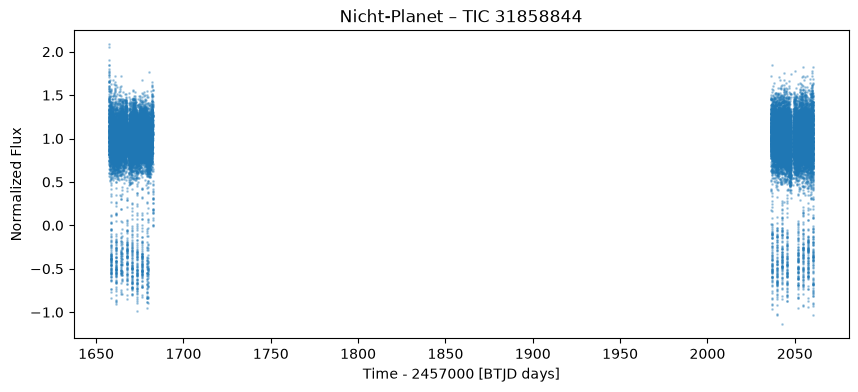

In [51]:
plt.figure(figsize=(10, 4))

plt.scatter(
    negative_lc_all.time.value,
    negative_lc_all.flux.value,
    s=1,
    alpha=0.3
)

plt.xlabel("Time - 2457000 [BTJD days]")
plt.ylabel("Normalized Flux")
plt.title(
    f"Nicht-Planet – TIC {negative_tic_id}"
)

plt.show()

#### Local-View-Fenster berechnen

In [52]:
negative_period = float(
    negative_example["pl_orbper"]
)

negative_transit_mid_bjd = float(
    negative_example["pl_tranmid"]
)

negative_duration_hours = float(
    negative_example["pl_trandurh"]
)

negative_transit_mid_btjd = (
    negative_transit_mid_bjd - 2457000
)

negative_duration_days = (
    negative_duration_hours / 24
)

negative_duration_phase = (
    negative_duration_days / negative_period
)

negative_window = (
    5 * negative_duration_phase
)

print("Periode:", negative_period, "Tage")
print(
    "Transitdauer:",
    negative_duration_hours,
    "Stunden"
)
print(
    "Local-View-Fenster:",
    negative_window
)

Periode: 2.9776152 Tage
Transitdauer: 3.25697 Stunden
Local-View-Fenster: 0.22787881277159883


#### Phase Folding Nicht-Planet

In [53]:
negative_folded = negative_lc_all.fold(
    period=negative_period,
    epoch_time=negative_transit_mid_btjd,
    normalize_phase=True
)

negative_phase = negative_folded.time.value
negative_flux = negative_folded.flux.value

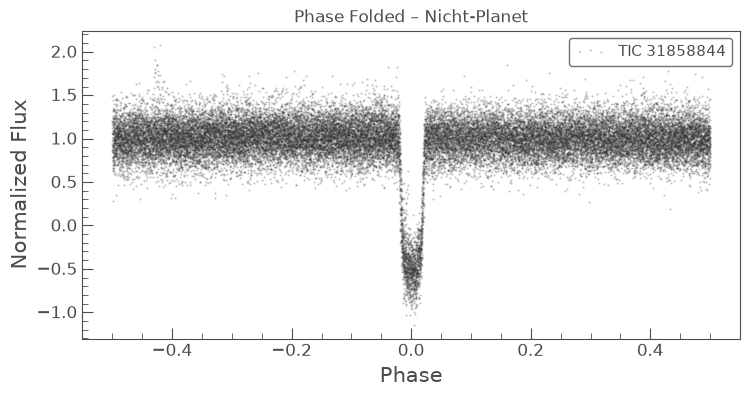

In [54]:
negative_folded.scatter(
    s=2,
    alpha=0.2
)

plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.title("Phase Folded – Nicht-Planet")

plt.show()

In [55]:
negative_local_mask = (
    np.abs(negative_phase)
    <= negative_window
)

negative_local_centers, negative_local_binned = (
    bin_phase_curve(
        phase=negative_phase[
            negative_local_mask
        ],
        flux=negative_flux[
            negative_local_mask
        ],
        phase_min=-negative_window,
        phase_max=negative_window,
        n_bins=n_local_bins
    )
)

print(
    "Local View:",
    len(negative_local_binned),
    "Bins | leere Bins:",
    np.isnan(negative_local_binned).sum()
)

Local View: 201 Bins | leere Bins: 0


In [56]:
negative_global_centers, negative_global_binned = (
    bin_phase_curve(
        phase=negative_phase,
        flux=negative_flux,
        phase_min=-0.5,
        phase_max=0.5,
        n_bins=n_global_bins
    )
)

print(
    "Global View:",
    len(negative_global_binned),
    "Bins | leere Bins:",
    np.isnan(negative_global_binned).sum()
)

Global View: 2001 Bins | leere Bins: 0


In [57]:
negative_local_view = (
    negative_local_binned
    - np.nanmedian(negative_local_binned)
)

negative_global_view = (
    negative_global_binned
    - np.nanmedian(negative_global_binned)
)

print(
    "Global Shape:",
    negative_global_view.shape
)

print(
    "Local Shape:",
    negative_local_view.shape
)

Global Shape: (2001,)
Local Shape: (201,)


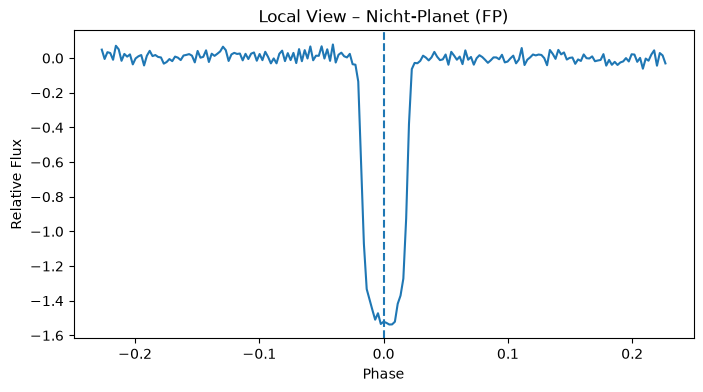

In [58]:
plt.figure(figsize=(8, 4))

plt.plot(
    negative_local_centers,
    negative_local_view
)

plt.axvline(0, linestyle="--")

plt.xlabel("Phase")
plt.ylabel("Relative Flux")
plt.title(
    f"Local View – Nicht-Planet ({negative_example['tfopwg_disp']})"
)

plt.show()

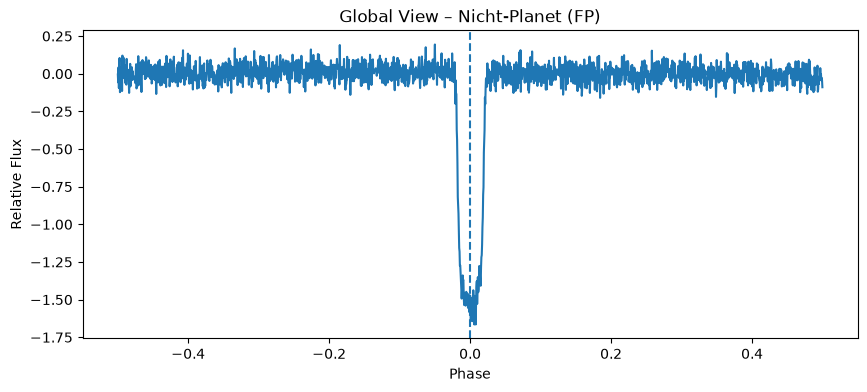

In [59]:
plt.figure(figsize=(10, 4))

plt.plot(
    negative_global_centers,
    negative_global_view
)

plt.axvline(0, linestyle="--")

plt.xlabel("Phase")
plt.ylabel("Relative Flux")
plt.title(
    f"Global View – Nicht-Planet ({negative_example['tfopwg_disp']})"
)

plt.show()

#### Verarbeitungsschritte zusammenfassen

In [61]:
def process_toi(row, n_global_bins=2001, n_local_bins=201):
    tic_id = int(row["tid"])

    period = float(row["pl_orbper"])
    transit_mid_bjd = float(row["pl_tranmid"])
    duration_hours = float(row["pl_trandurh"])

    transit_mid_btjd = transit_mid_bjd - 2457000

    duration_days = duration_hours / 24
    duration_phase = duration_days / period
    local_window = 5 * duration_phase

    # SPOC-120-s-Lichtkurven suchen
    search = lk.search_lightcurve(
        f"TIC {tic_id}",
        mission="TESS",
        author="SPOC",
        exptime=120
    )

    if len(search) == 0:
        return None

    lightcurves = search.download_all()

    normalized = []

    for lc_sector in lightcurves:
        lc_sector = lc_sector.remove_nans()

        if len(lc_sector) == 0:
            continue

        lc_sector = lc_sector.normalize()

        normalized.append(lc_sector)

    if len(normalized) == 0:
        return None

    # Sektoren zusammenführen
    lc_all = lk.LightCurveCollection(
        normalized
    ).stitch(
        corrector_func=lambda x: x
    )

    # Phase Folding
    folded = lc_all.fold(
        period=period,
        epoch_time=transit_mid_btjd,
        normalize_phase=True
    )

    phase = folded.time.value
    flux = folded.flux.value

    # Global View
    global_centers, global_flux = bin_phase_curve(
        phase,
        flux,
        -0.5,
        0.5,
        n_global_bins
    )

    # Local View
    local_mask = np.abs(phase) <= local_window

    local_centers, local_flux = bin_phase_curve(
        phase[local_mask],
        flux[local_mask],
        -local_window,
        local_window,
        n_local_bins
    )

    # Zentrieren
    global_flux = (
        global_flux - np.nanmedian(global_flux)
    )

    local_flux = (
        local_flux - np.nanmedian(local_flux)
    )

    return {
        "toi": row["toi"],
        "tid": tic_id,
        "label": int(row["label"]),
        "disposition": row["tfopwg_disp"],
        "n_sectors": len(normalized),
        "global_view": global_flux,
        "local_view": local_flux,
        "global_phase": global_centers,
        "local_phase": local_centers
    }

In [62]:
planet_result = process_toi(
    planet_example
)

print("TOI:", planet_result["toi"])
print("TIC:", planet_result["tid"])
print("Label:", planet_result["label"])
print("Sektoren:", planet_result["n_sectors"])

print(
    "Global Shape:",
    planet_result["global_view"].shape
)

print(
    "Local Shape:",
    planet_result["local_view"].shape
)

TOI: 1064.01
TIC: 79748331
Label: 1
Sektoren: 6
Global Shape: (2001,)
Local Shape: (201,)


In [63]:
negative_result = process_toi(
    negative_example
)

print("TOI:", negative_result["toi"])
print("TIC:", negative_result["tid"])
print("Label:", negative_result["label"])
print("Disposition:", negative_result["disposition"])
print("Sektoren:", negative_result["n_sectors"])

print(
    "Global Shape:",
    negative_result["global_view"].shape
)

print(
    "Local Shape:",
    negative_result["local_view"].shape
)

TOI: 1070.01
TIC: 31858844
Label: 0
Disposition: FP
Sektoren: 2
Global Shape: (2001,)
Local Shape: (201,)


#### Local View von Planet und Nicht-Planet

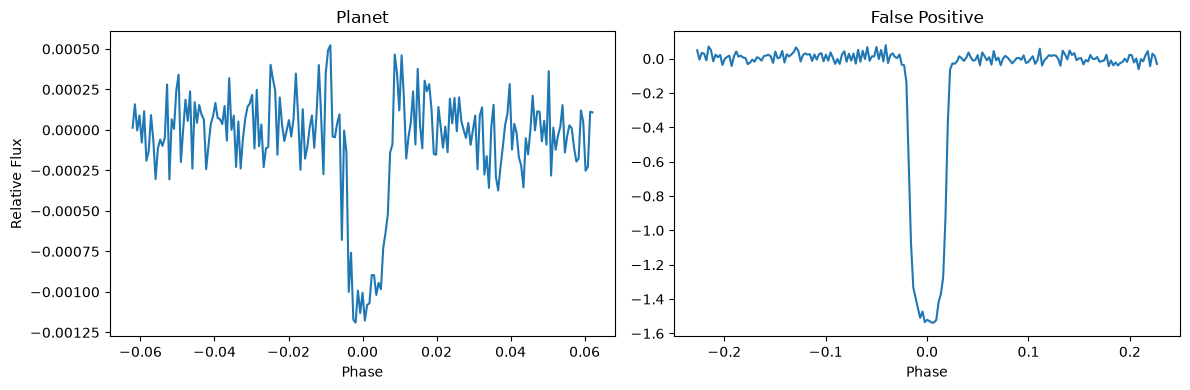

In [64]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].plot(
    planet_result["local_phase"],
    planet_result["local_view"]
)

axes[0].set_title("Planet")
axes[0].set_xlabel("Phase")
axes[0].set_ylabel("Relative Flux")

axes[1].plot(
    negative_result["local_phase"],
    negative_result["local_view"]
)

axes[1].set_title("False Positive")
axes[1].set_xlabel("Phase")

plt.tight_layout()
plt.show()

### Pilotversuch mit 10 TOIs

In [65]:
pilot_planets = (
    supervised[supervised["label"] == 1]
    .drop_duplicates(subset="tid")
    .sample(n=5, random_state=42)
)

pilot_non_planets = (
    supervised[supervised["label"] == 0]
    .drop_duplicates(subset="tid")
    .sample(n=5, random_state=42)
)

pilot = pd.concat(
    [pilot_planets, pilot_non_planets],
    ignore_index=True
)

pilot[
    ["toi", "tid", "tfopwg_disp", "label"]
]

,toi,tid,tfopwg_disp,label
0,2977.01,361343239,CP,1
1,4485.01,137903329,KP,1
2,4538.01,262715204,KP,1
3,1721.01,51234631,KP,1
4,1180.01,158002130,CP,1
5,4134.01,420803693,FP,0
6,644.01,63303499,FP,0
7,975.01,133654092,FP,0
8,1647.01,154927364,FP,0
9,1496.01,384045439,FP,0


In [66]:
pilot["label"].value_counts()

label
1    5
0    5
Name: count, dtype: int64

In [ ]:
pilot_results = []
pilot_audit = []

for _, row in tqdm(
    pilot.iterrows(),
    total=len(pilot)
):
    try:
        result = process_toi(row)

        if result is None:
            pilot_audit.append({
                "toi": row["toi"],
                "tid": row["tid"],
                "label": row["label"],
                "status": "no_spoc_120",
                "n_sectors": 0,
                "global_nan": None,
                "local_nan": None
            })

            continue

        global_nan = np.isnan(
            result["global_view"]
        ).sum()

        local_nan = np.isnan(
            result["local_view"]
        ).sum()

        pilot_results.append(result)

        pilot_audit.append({
            "toi": result["toi"],
            "tid": result["tid"],
            "label": result["label"],
            "status": "success",
            "n_sectors": result["n_sectors"],
            "global_nan": global_nan,
            "local_nan": local_nan
        })

    except Exception as e:
        pilot_audit.append({
            "toi": row["toi"],
            "tid": row["tid"],
            "label": row["label"],
            "status": f"error: {e}",
            "n_sectors": None,
            "global_nan": None,
            "local_nan": None
        })

In [68]:
pilot_audit_df = pd.DataFrame(
    pilot_audit
)

pilot_audit_df

,toi,tid,label,status,n_sectors,global_nan,local_nan
0,2977.01,361343239,1,success,3,0,0
1,4485.01,137903329,1,success,8,0,0
2,4538.01,262715204,1,success,3,0,0
3,1721.01,51234631,1,success,4,0,0
4,1180.01,158002130,1,success,15,0,0
5,4134.01,420803693,0,success,2,0,0
6,644.01,63303499,0,success,2,0,0
7,975.01,133654092,0,success,2,0,0
8,1647.01,154927364,0,success,4,0,0
9,1496.01,384045439,0,success,2,0,0


In [69]:
print("Pilot-TOIs:", len(pilot))

print(
    "Erfolgreich verarbeitet:",
    (pilot_audit_df["status"] == "success").sum()
)

print(
    "Ohne SPOC-120-s:",
    (pilot_audit_df["status"] == "no_spoc_120").sum()
)

print()
print("Status:")
print(
    pilot_audit_df["status"].value_counts()
)

Pilot-TOIs: 10
Erfolgreich verarbeitet: 10
Ohne SPOC-120-s: 0

Status:
status
success    10
Name: count, dtype: int64


#### Daten der Test-Objekte

In [70]:
successful = pilot_audit_df[
    pilot_audit_df["status"] == "success"
]

successful[
    [
        "toi",
        "label",
        "n_sectors",
        "global_nan",
        "local_nan"
    ]
]

,toi,label,n_sectors,global_nan,local_nan
0,2977.01,1,3,0,0
1,4485.01,1,8,0,0
2,4538.01,1,3,0,0
3,1721.01,1,4,0,0
4,1180.01,1,15,0,0
5,4134.01,0,2,0,0
6,644.01,0,2,0,0
7,975.01,0,2,0,0
8,1647.01,0,4,0,0
9,1496.01,0,2,0,0


In [71]:
print(
    "TOIs mit leeren Global-Bins:",
    (successful["global_nan"] > 0).sum()
)

print(
    "TOIs mit leeren Local-Bins:",
    (successful["local_nan"] > 0).sum()
)

TOIs mit leeren Global-Bins: 0
TOIs mit leeren Local-Bins: 0


In [72]:
successful[
    (successful["global_nan"] > 0)
    | (successful["local_nan"] > 0)
]

,toi,tid,label,status,n_sectors,global_nan,local_nan


In [73]:
for result in pilot_results:
    print(
        f"TOI {result['toi']} | "
        f"Label {result['label']} | "
        f"Global {result['global_view'].shape} | "
        f"Local {result['local_view'].shape}"
    )

TOI 2977.01 | Label 1 | Global (2001,) | Local (201,)
TOI 4485.01 | Label 1 | Global (2001,) | Local (201,)
TOI 4538.01 | Label 1 | Global (2001,) | Local (201,)
TOI 1721.01 | Label 1 | Global (2001,) | Local (201,)
TOI 1180.01 | Label 1 | Global (2001,) | Local (201,)
TOI 4134.01 | Label 0 | Global (2001,) | Local (201,)
TOI 644.01 | Label 0 | Global (2001,) | Local (201,)
TOI 975.01 | Label 0 | Global (2001,) | Local (201,)
TOI 1647.01 | Label 0 | Global (2001,) | Local (201,)
TOI 1496.01 | Label 0 | Global (2001,) | Local (201,)


### Speichern der Daten

In [74]:
PILOT_DIR = INTERIM_DIR / "pilot"

PILOT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [75]:
for result in pilot_results:
    toi_id = str(result["toi"]).replace(".", "_")

    np.save(
        PILOT_DIR / f"toi_{toi_id}_global.npy",
        result["global_view"]
    )

    np.save(
        PILOT_DIR / f"toi_{toi_id}_local.npy",
        result["local_view"]
    )

In [76]:
pilot_audit_df.to_csv(
    PILOT_DIR / "pilot_audit.csv",
    index=False
)

print("Gespeichert unter:")
print(PILOT_DIR)

Gespeichert unter:
c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\pilot


In [77]:
pilot_audit_df.groupby("label")["n_sectors"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
label,,,,,
0,5,2.4,2.0,2,4
1,5,6.6,4.0,3,15


### Vollständige SPOC-Verfügbarkeitsprüfung

In [89]:
full_audit_targets = supervised[
    [
        "toi",
        "tid",
        "tfopwg_disp",
        "label"
    ]
].copy()

unique_tics = (
    full_audit_targets[
        ["tid"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Gelabelte TOIs:", len(full_audit_targets))
print("Einzigartige TIC-IDs:", len(unique_tics))

Gelabelte TOIs: 2663
Einzigartige TIC-IDs: 2524


In [90]:
SPOC_CHECKPOINT_FILE = (
    INTERIM_DIR / "spoc_120_availability_checkpoint.csv"
)

SPOC_FINAL_FILE = (
    INTERIM_DIR / "spoc_120_availability_by_tid.csv"
)

CHECKPOINT_EVERY = 25


if SPOC_FINAL_FILE.exists():

    checkpoint_df = pd.read_csv(
        SPOC_FINAL_FILE
    )

    print("Bereits vorhandene Final-Datei geladen.")

elif SPOC_CHECKPOINT_FILE.exists():

    checkpoint_df = pd.read_csv(
        SPOC_CHECKPOINT_FILE
    )

    print("Vorhandener Checkpoint geladen.")

else:

    checkpoint_df = pd.DataFrame()

    print("Noch kein gespeicherter Stand vorhanden.")


if len(checkpoint_df) > 0:

    checkpoint_df = (
        checkpoint_df
        .drop_duplicates(
            subset="tid",
            keep="last"
        )
        .reset_index(drop=True)
    )

    spoc_availability = (
        checkpoint_df.to_dict("records")
    )

else:

    spoc_availability = []

Noch kein gespeicherter Stand vorhanden.


In [91]:
processed_tics = {
    int(result["tid"])
    for result in spoc_availability
    if result["search_status"] == "ok"
}

pending_tics = [
    int(tic_id)
    for tic_id in unique_tics["tid"]
    if int(tic_id) not in processed_tics
]

print(
    f"Erfolgreich geprüft: "
    f"{len(processed_tics)} TICs"
)

print(
    f"Noch zu prüfen: "
    f"{len(pending_tics)} TICs"
)

print(
    "Checkpoint-Datei:",
    SPOC_CHECKPOINT_FILE
)

Erfolgreich geprüft: 0 TICs
Noch zu prüfen: 2524 TICs
Checkpoint-Datei: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\spoc_120_availability_checkpoint.csv


In [92]:
new_since_checkpoint = 0

try:

    for tic_id in tqdm(
        pending_tics,
        total=len(pending_tics),
        desc="SPOC-Verfügbarkeit"
    ):

        try:

            search = lk.search_lightcurve(
                f"TIC {tic_id}",
                mission="TESS",
                author="SPOC",
                exptime=120
            )

            result = {
                "tid": tic_id,
                "search_status": "ok",
                "spoc_120_available": (
                    len(search) > 0
                ),
                "n_sectors": len(search),
                "error_message": None
            }

        except Exception as e:

            result = {
                "tid": tic_id,
                "search_status": "error",
                "spoc_120_available": np.nan,
                "n_sectors": np.nan,
                "error_message": str(e)
            }

        spoc_availability.append(
            result
        )

        new_since_checkpoint += 1

        if (
            new_since_checkpoint
            >= CHECKPOINT_EVERY
        ):

            checkpoint_df = (
                pd.DataFrame(
                    spoc_availability
                )
                .drop_duplicates(
                    subset="tid",
                    keep="last"
                )
            )

            checkpoint_df.to_csv(
                SPOC_CHECKPOINT_FILE,
                index=False
            )

            new_since_checkpoint = 0


finally:

    checkpoint_df = (
        pd.DataFrame(
            spoc_availability
        )
        .drop_duplicates(
            subset="tid",
            keep="last"
        )
    )

    checkpoint_df.to_csv(
        SPOC_CHECKPOINT_FILE,
        index=False
    )

    print()
    print(
        "Aktueller Stand gespeichert:",
        len(checkpoint_df),
        "TICs"
    )

SPOC-Verfügbarkeit:   0%|          | 0/2524 [00:00<?, ?it/s]


Aktueller Stand gespeichert: 2524 TICs


In [93]:
spoc_by_tid_df = (
    pd.DataFrame(
        spoc_availability
    )
    .drop_duplicates(
        subset="tid",
        keep="last"
    )
    .sort_values("tid")
    .reset_index(drop=True)
)

In [94]:
n_expected = len(unique_tics)
n_results = len(spoc_by_tid_df)

n_errors = (
    spoc_by_tid_df[
        "search_status"
    ] == "error"
).sum()

n_missing = (
    n_expected - n_results
)

print(
    "Einzigartige TICs erwartet:",
    n_expected
)

print(
    "TICs gespeichert:",
    n_results
)

print(
    "Fehlende TICs:",
    n_missing
)

print(
    "Fehlerhafte MAST-Abfragen:",
    n_errors
)

Einzigartige TICs erwartet: 2524
TICs gespeichert: 2524
Fehlende TICs: 0
Fehlerhafte MAST-Abfragen: 0


In [95]:
spoc_by_tid_df[
    spoc_by_tid_df[
        "search_status"
    ] == "error"
]

,tid,search_status,spoc_120_available,n_sectors,error_message


#### Speichert vollständig geprüfte SPOC-Verfügbarkeiten

In [96]:
if n_missing == 0 and n_errors == 0:

    spoc_by_tid_df.to_csv(
        SPOC_FINAL_FILE,
        index=False
    )

    print(
        "Final gespeichert:",
        len(spoc_by_tid_df),
        "TICs"
    )

    print(
        "Datei:",
        SPOC_FINAL_FILE
    )

else:

    print(
        "Noch keine Final-Datei erzeugt."
    )

    print(
        "Bitte fehlende oder fehlerhafte "
        "TICs erneut prüfen."
    )

Final gespeichert: 2524 TICs
Datei: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\spoc_120_availability_by_tid.csv


#### TIC auf einzelne TOIs übertragen

In [97]:
full_availability_df = (
    full_audit_targets
    .merge(
        spoc_by_tid_df,
        on="tid",
        how="left"
    )
)

full_availability_df.head()

,toi,tid,tfopwg_disp,label,search_status,spoc_120_available,n_sectors,error_message
0,1064.01,79748331,CP,1,ok,True,6,None
1,1064.02,79748331,CP,1,ok,True,6,None
2,1065.01,7088246,KP,1,ok,True,4,None
3,1066.01,201604954,KP,1,ok,True,5,None
4,1067.01,201642601,KP,1,ok,True,7,None


In [98]:
print(
    "TOIs erwartet:",
    len(full_audit_targets)
)

print(
    "TOIs nach Merge:",
    len(full_availability_df)
)

print(
    "Fehlende SPOC-Angaben:",
    full_availability_df[
        "search_status"
    ].isna().sum()
)

TOIs erwartet: 2663
TOIs nach Merge: 2663
Fehlende SPOC-Angaben: 0


#### Vollständige TOI-Tabelle inklusive SPOC speichern

In [99]:
FULL_AVAILABILITY_FILE = (
    INTERIM_DIR
    / "spoc_120_full_availability.csv"
)

full_availability_df.to_csv(
    FULL_AVAILABILITY_FILE,
    index=False
)

print(
    "Vollständige TOI-Tabelle gespeichert:"
)

print(
    FULL_AVAILABILITY_FILE
)

Vollständige TOI-Tabelle gespeichert:
c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\spoc_120_full_availability.csv


In [100]:
FULL_AVAILABILITY_FILE = (
    INTERIM_DIR
    / "spoc_120_full_availability.csv"
)

SPOC_FINAL_FILE = (
    INTERIM_DIR
    / "spoc_120_availability_by_tid.csv"
)

full_availability_df = pd.read_csv(
    FULL_AVAILABILITY_FILE
)

spoc_by_tid_df = pd.read_csv(
    SPOC_FINAL_FILE
)

print(
    "Full Availability:",
    full_availability_df.shape
)

print(
    "By TIC:",
    spoc_by_tid_df.shape
)

Full Availability: (2663, 8)
By TIC: (2524, 5)


In [101]:
availability_by_label = (
    full_availability_df
    .groupby("label")["spoc_120_available"]
    .agg(
        total="count",
        available="sum",
        fraction="mean"
    )
)

availability_by_label[
    "percent_available"
] = (
    availability_by_label["fraction"] * 100
)

availability_by_label

,total,available,fraction,percent_available
label,,,,
0,1339,1087,0.811800,81.179985
1,1324,1311,0.990181,99.018127


#### Filtern auf TOI mit den verfügbaren SPOC-120s-Daten

In [102]:
usable_spoc = full_availability_df[
    (
        full_availability_df["search_status"] == "ok"
    )
    &
    (
        full_availability_df["spoc_120_available"] == True
    )
].copy()

print("Vor SPOC-Filter:")
print(
    full_availability_df[
        "label"
    ].value_counts().sort_index()
)

print()

print("Nach SPOC-Filter:")
print(
    usable_spoc[
        "label"
    ].value_counts().sort_index()
)

print()

print("Klassenanteile nach Filter:")
print(
    usable_spoc[
        "label"
    ].value_counts(
        normalize=True
    ).sort_index()
)

Vor SPOC-Filter:
label
0    1339
1    1324
Name: count, dtype: int64

Nach SPOC-Filter:
label
0    1087
1    1311
Name: count, dtype: int64

Klassenanteile nach Filter:
label
0    0.453294
1    0.546706
Name: proportion, dtype: float64


#### Anzahl verfügbarer Sektoren auf beide Klassen vergleichen

In [103]:
sector_summary = (
    usable_spoc
    .groupby("label")["n_sectors"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max"
        ]
    )
)

sector_summary

,count,mean,median,min,max
label,,,,,
0,1087,5.908924,3.0,1,44
1,1311,7.781846,5.0,1,44


#### SPOC-Verfügbarkeit auf den Klassen CP, KP, FP und FA

In [104]:
disposition_summary = (
    full_availability_df
    .groupby("tfopwg_disp")
    .agg(
        n_tois=("toi", "count"),
        spoc_available=(
            "spoc_120_available",
            "sum"
        ),
        mean_sectors=(
            "n_sectors",
            "mean"
        ),
        median_sectors=(
            "n_sectors",
            "median"
        )
    )
)

disposition_summary[
    "percent_available"
] = (
    disposition_summary[
        "spoc_available"
    ]
    / disposition_summary[
        "n_tois"
    ]
    * 100
)

disposition_summary

,n_tois,spoc_available,mean_sectors,median_sectors,percent_available
tfopwg_disp,,,,,
CP,737,725,9.833107,5.0,98.371777
FA,95,93,12.368421,5.0,97.894737
FP,1244,994,4.218650,2.0,79.903537
KP,587,586,5.034072,4.0,99.829642


### Finaler Datensatz

#### Sicher gelabelte TOIs und SPOC miteinander Verknüpfen und finalen Datensatz erstellen

In [105]:
availability_columns = [
    "toi",
    "search_status",
    "spoc_120_available",
    "n_sectors"
]

supervised_manifest = supervised.merge(
    full_availability_df[availability_columns],
    on="toi",
    how="left",
    validate="one_to_one"
)

usable_manifest = supervised_manifest[
    (supervised_manifest["search_status"] == "ok")
    & (supervised_manifest["spoc_120_available"] == True)
].copy()

usable_manifest = usable_manifest.reset_index(drop=True)

print("Supervised TOIs insgesamt:", len(supervised_manifest))
print("Mit SPOC-120-s:", len(usable_manifest))
print("Eindeutige TIC-IDs:", usable_manifest["tid"].nunique())

print()
print("Klassen:")
print(
    usable_manifest["label"]
    .value_counts()
    .sort_index()
)

Supervised TOIs insgesamt: 2663
Mit SPOC-120-s: 2398
Eindeutige TIC-IDs: 2259

Klassen:
label
0    1087
1    1311
Name: count, dtype: int64


#### Prüfung, wie viele TICs mehrere TOIs besitzen

In [106]:
tois_per_star = (
    usable_manifest
    .groupby("tid")
    .size()
    .sort_values(ascending=False)
)

print(
    "Sterne mit mehr als einem TOI:",
    (tois_per_star > 1).sum()
)

print(
    "Maximale Anzahl TOIs bei einem Stern:",
    tois_per_star.max()
)

Sterne mit mehr als einem TOI: 103
Maximale Anzahl TOIs bei einem Stern: 5


In [107]:
labels_per_star = (
    usable_manifest
    .groupby("tid")["label"]
    .nunique()
)

mixed_label_tics = (
    labels_per_star[
        labels_per_star > 1
    ]
    .index
)

print(
    "TICs mit Planet- und Nicht-Planet-TOIs:",
    len(mixed_label_tics)
)

TICs mit Planet- und Nicht-Planet-TOIs: 5


In [108]:
usable_manifest[
    usable_manifest["tid"].isin(
        mixed_label_tics
    )
][
    [
        "toi",
        "tid",
        "tfopwg_disp",
        "label"
    ]
].sort_values(
    ["tid", "toi"]
)

,toi,tid,tfopwg_disp,label
1206,282.01,29781292,CP,1
1207,282.02,29781292,FA,0
1208,282.03,29781292,CP,1
1209,282.04,29781292,CP,1
2233,712.01,150151262,CP,1
2234,712.02,150151262,CP,1
2235,712.03,150151262,FA,0
2236,712.04,150151262,CP,1
590,1836.01,207468071,CP,1
591,1836.02,207468071,FP,0


### Dataset-Split
70% Training, 15% Validation, 15% Test

In [109]:
from sklearn.model_selection import StratifiedGroupKFold

#### Nach TIC-ID gruppierten, stratifizierten Split erstellen

In [110]:
splitter = StratifiedGroupKFold(
    n_splits=20,
    shuffle=True,
    random_state=42
)

group_fold = np.empty(
    len(usable_manifest),
    dtype=int
)

for fold_id, (_, fold_indices) in enumerate(
    splitter.split(
        X=usable_manifest,
        y=usable_manifest["label"],
        groups=usable_manifest["tid"]
    )
):
    group_fold[fold_indices] = fold_id

usable_manifest["group_fold"] = group_fold

#### Zuordnung der Folds

In [111]:
usable_manifest["split"] = np.select(
    [
        usable_manifest["group_fold"] < 14,
        usable_manifest["group_fold"] < 17
    ],
    [
        "train",
        "validation"
    ],
    default="test"
)

### Split kontrollieren

In [112]:
split_counts = (
    usable_manifest["split"]
    .value_counts()
    .reindex(
        ["train", "validation", "test"]
    )
)

split_percent = (
    split_counts
    / len(usable_manifest)
    * 100
)

split_summary = pd.DataFrame({
    "n_tois": split_counts,
    "percent": split_percent
})

split_summary

,n_tois,percent
split,,
train,1681,70.100083
validation,360,15.012510
test,357,14.887406


In [113]:
class_counts_by_split = pd.crosstab(
    usable_manifest["split"],
    usable_manifest["label"]
)

class_counts_by_split = (
    class_counts_by_split
    .reindex(
        ["train", "validation", "test"]
    )
)

class_counts_by_split

label,0,1
split,,
train,763,918
validation,162,198
test,162,195


In [114]:
class_proportions_by_split = (
    pd.crosstab(
        usable_manifest["split"],
        usable_manifest["label"],
        normalize="index"
    )
    .reindex(
        ["train", "validation", "test"]
    )
)

class_proportions_by_split

label,0,1
split,,
train,0.453896,0.546104
validation,0.450000,0.550000
test,0.453782,0.546218


#### Gespeicherte Manifestdatei laden

In [116]:
print(
    "TOIs:",
    len(usable_manifest)
)

print(
    "Eindeutige TOIs:",
    usable_manifest["toi"].nunique()
)

print(
    "Eindeutige TICs:",
    usable_manifest["tid"].nunique()
)

print(
    "Fehlende Split-Zuweisungen:",
    usable_manifest["split"].isna().sum()
)

print(
    "Fehlende Labels:",
    usable_manifest["label"].isna().sum()
)

print(
    "Fehlende Perioden:",
    usable_manifest["pl_orbper"].isna().sum()
)

print(
    "Fehlende Transitzeitpunkte:",
    usable_manifest["pl_tranmid"].isna().sum()
)

print(
    "Fehlende Transitdauern:",
    usable_manifest["pl_trandurh"].isna().sum()
)

TOIs: 2398
Eindeutige TOIs: 2398
Eindeutige TICs: 2259
Fehlende Split-Zuweisungen: 0
Fehlende Labels: 0
Fehlende Perioden: 0
Fehlende Transitzeitpunkte: 0
Fehlende Transitdauern: 0


In [117]:
MANIFEST_FILE = (
    INTERIM_DIR
    / f"toi_spoc120_manifest_{snapshot_date}.csv"
)

usable_manifest.to_csv(
    MANIFEST_FILE,
    index=False
)

print(
    "Manifest gespeichert:"
)

print(
    MANIFEST_FILE
)

Manifest gespeichert:
c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\toi_spoc120_manifest_2026-08-16.csv


In [119]:
manifest_check = pd.read_csv(
    MANIFEST_FILE
)

print(
    "Gespeicherte Zeilen:",
    len(manifest_check)
)

print()

print(
    manifest_check["split"]
    .value_counts()
)

print()

print(
    manifest_check["label"]
    .value_counts()
)

Gespeicherte Zeilen: 2398

split
train         1681
validation     360
test           357
Name: count, dtype: int64

label
1    1311
0    1087
Name: count, dtype: int64


### Abschluss Datenexploration

Für den supervised Datensatz werden nur sicher klassifizierte
TOIs mit  den vollständigen Transitparametern "CP und KP → Planet (`label = 1`)" und "FP und FA → Nicht-Planet (`label = 0`)" verwendet.

Als Lichtkurvenquelle werden SPOC-Lichtkurven mit einer Kadenz von
120 Sekunden verwendet.

Von 2663 sicher gelabelten TOIs mit vollständigen Transitparametern
besitzen 2398 (1311 Planeten, 1087 Nicht-Planeten) mindestens eine SPOC-120-s-Lichtkurve.

Die SPOC-120s-Verfügbarkeit unterscheidet sich je nach
Disposition. Insbesondere FP-Kandidaten besitzen seltener entsprechende
Lichtkurven. Bei der Interpretation der Ergebnisse wird diese Auswahl
als mögliche Einschränkung des Datensatzes berücksichtigt.

Da sich auch die Anzahl verfügbarer Sektoren zwischen den Kandidaten
unterscheidet, wird für zunächst pro TOI
genau ein SPOC-120-s-Sektor verwendet. Die konkrete
Sektorauswahl erfolgt bei der Datensatzgenerierung.

Trainings-, Validierungs- und Testdaten werden nach TIC-ID gruppiert,
sodass TOIs desselben Sterns ausschließlich demselben Split
zugeordnet werden. Dadurch wird Daten-Leakage zwischen den Splits
vermieden.

Der Testdatensatz bleibt für alle späteren Experimente unverändert.

In [120]:
print("Notebook 02 abgeschlossen.")
print()

print(
    f"Verwendbare TOIs: "
    f"{len(usable_manifest)}"
)

print(
    f"Eindeutige TICs: "
    f"{usable_manifest['tid'].nunique()}"
)

print()

print("Split:")
print(
    usable_manifest["split"]
    .value_counts()
    .reindex(
        ["train", "validation", "test"]
    )
)

print()

print(
    "Manifest:",
    MANIFEST_FILE
)

Notebook 02 abgeschlossen.

Verwendbare TOIs: 2398
Eindeutige TICs: 2259

Split:
split
train         1681
validation     360
test           357
Name: count, dtype: int64

Manifest: c:\Users\user\Documents\HSFlensburgMaster\Sommersemester2026\AdvancedDeepLearning\Projekt\Exoplanets\data\interim\toi_spoc120_manifest_2026-08-16.csv
